In [1]:
import pandas as pd
df = pd.read_csv("Cyber_salaries.csv")
df

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2022,EN,FT,Information Security Officer,68000,EUR,72762,DE,100,DE,S
1,2022,SE,FT,Security Officer,123400,USD,123400,US,0,US,M
2,2022,SE,FT,Security Officer,88100,USD,88100,US,0,US,M
3,2022,SE,FT,Security Engineer,163575,USD,163575,US,100,US,M
4,2022,SE,FT,Security Engineer,115800,USD,115800,US,100,US,M
...,...,...,...,...,...,...,...,...,...,...,...
1344,2020,MI,FT,Cyber Security Analyst,140000,AUD,96422,AU,50,AU,M
1345,2021,SE,FT,Information Security Manager,60000,GBP,82528,GB,50,GB,L
1346,2021,SE,FT,Penetration Testing Engineer,126000,USD,126000,US,100,US,L
1347,2021,MI,FT,Information Security Analyst,42000,GBP,57769,GB,100,GB,L


In [2]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [3]:
df.rename(columns={
    "work_year":"Work_Year"
},inplace=True)

In [4]:
df.columns

Index(['Work_Year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='str')

In [5]:
df.isnull().sum()

Work_Year             0
experience_level      0
employment_type       0
job_title             0
salary                0
salary_currency       0
salary_in_usd         0
employee_residence    0
remote_ratio          0
company_location      0
company_size          0
dtype: int64

In [6]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
1344    False
1345    False
1346    False
1347    False
1348    False
Length: 1349, dtype: bool

In [7]:
df.sort_values("salary",ascending=False).head(15)

,Work_Year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
718,2022,SE,FT,Incident Response Lead,500000000,IDR,34303,ID,100,ID,L
970,2021,MI,FT,IT Security Engineer,10320000,HUF,34018,HU,50,HU,M
1165,2021,EX,FT,Principal Security Engineer,3800000,INR,51389,IN,100,GB,S
1079,2021,MI,FT,Application Security Engineer,3600000,INR,48684,IN,0,IN,M
887,2021,SE,FT,Information Security Manager,3200000,INR,43275,IN,0,IN,L
888,2021,MI,FT,Cyber Security Analyst,3200000,INR,43275,IN,0,IN,L
1112,2021,MI,FT,Application Security Engineer,1600000,INR,21637,IN,0,IN,L
456,2022,SE,FT,Information Security Manager,1600000,INR,20741,IN,0,BR,L
591,2022,SE,FT,Cyber Security Engineer,1500000,INR,19445,IN,0,IN,S
1263,2021,MI,FT,Cyber Security Researcher,1500000,INR,20285,IN,0,IN,M


In [8]:
df.drop_duplicates()

,Work_Year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2022,EN,FT,Information Security Officer,68000,EUR,72762,DE,100,DE,S
1,2022,SE,FT,Security Officer,123400,USD,123400,US,0,US,M
2,2022,SE,FT,Security Officer,88100,USD,88100,US,0,US,M
3,2022,SE,FT,Security Engineer,163575,USD,163575,US,100,US,M
4,2022,SE,FT,Security Engineer,115800,USD,115800,US,100,US,M
...,...,...,...,...,...,...,...,...,...,...,...
1344,2020,MI,FT,Cyber Security Analyst,140000,AUD,96422,AU,50,AU,M
1345,2021,SE,FT,Information Security Manager,60000,GBP,82528,GB,50,GB,L
1346,2021,SE,FT,Penetration Testing Engineer,126000,USD,126000,US,100,US,L
1347,2021,MI,FT,Information Security Analyst,42000,GBP,57769,GB,100,GB,L


In [9]:
q1 = df['salary'].quantile(0.25)
q3 = df['salary'].quantile(0.75)

IQR = q3 - q1

lower_limit = q1 - 1.5 * IQR
upper_limit = q3 + 1.5 * IQR
print("Q1: ",q1)
print("Q3: ",q3)
print("IQR: ",IQR)
print("Lower: ",lower_limit)
print("Upper: ",upper_limit)
outliers = df[
    (df["salary"]<lower_limit) |
    (df["salary"]>upper_limit)
]
print("\nNumber of salary outliers: ",len(outliers))
print("\nsalary outliers:")
print(outliers[["salary","salary_in_usd"]].head(20))


Q1:  80000.0
Q3:  160080.0
IQR:  80080.0
Lower:  -40120.0
Upper:  280200.0

Number of salary outliers:  74

salary outliers:
      salary  salary_in_usd
107   315000         315000
111   360000         360000
116   290000         290000
122   450000           6072
129   300000         300000
159   450000          64717
161   500000           6481
223   750000          10142
237   292000         292000
408   300000         300000
456  1600000          20741
494   300000          58537
502  1400000          18148
506   325000         325000
519   410000         410000
535   315000          58390
577   950000          96806
591  1500000          19445
594   467000          23029
598   480000         145340


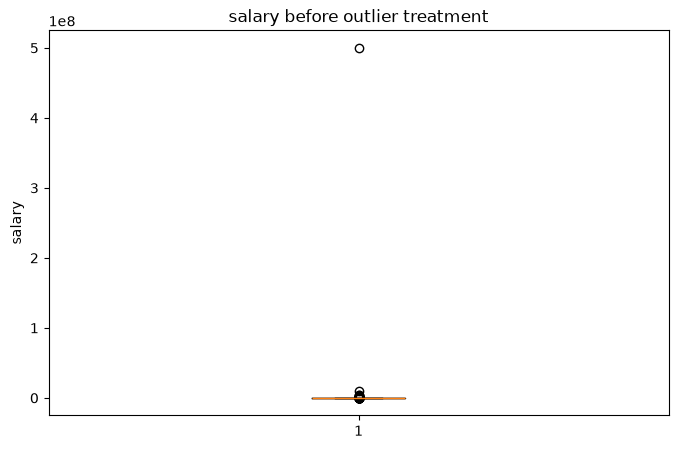

In [11]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.boxplot(df["salary"])
plt.title("salary before outlier treatment")
plt.ylabel('salary')
plt.show()

In [12]:
df['Salary_Updated'] = df['salary'].clip(
    lower = lower_limit,
    upper = upper_limit
)

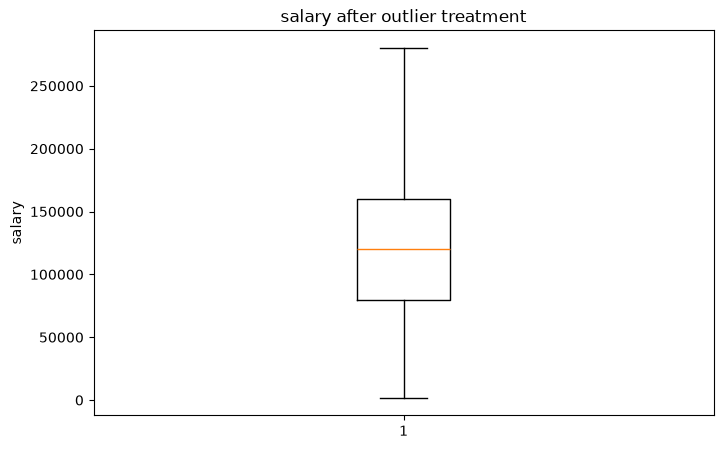

In [14]:

plt.figure(figsize=(8,5))
plt.boxplot(df["Salary_Updated"])
plt.title("salary after outlier treatment")
plt.ylabel('salary')
plt.show()

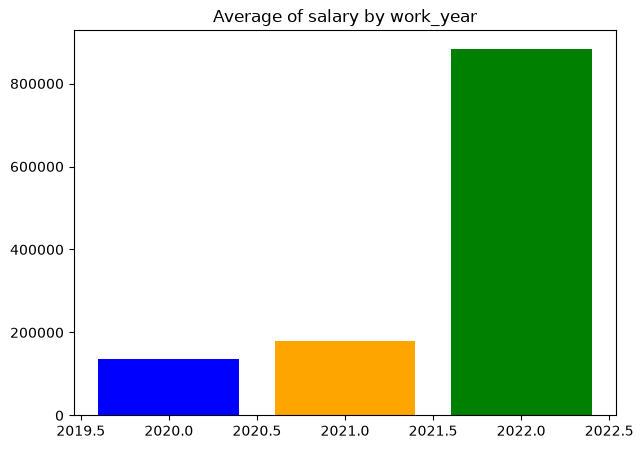

In [18]:
Average = df.groupby("Work_Year")['salary'].mean()
plt.figure(figsize=(7,5))
plt.bar(Average.index,Average.values,color=["blue","orange","green"])
plt.title("Average of salary by work_year")
plt.xlabel = ("Work_Year")
plt.ylabel = ("salary")
plt.show()


Average of salary_in_usd by company_location:
company_location
AE    170000.000000
AF     90000.000000
AQ     58537.000000
AR     50666.666667
AT     63240.000000
AU    128527.523810
AX     50000.000000
AZ      5800.000000
BA     12005.000000
BE     60768.000000
BR     47269.250000
BW    120000.000000
CA    119605.737705
CH    122022.357143
CL     50000.000000
CY     42801.000000
CZ     42000.000000
DE     82350.852941
DK     60427.166667
DZ     10100.000000
EE     47873.000000
EG     12800.000000
ES     52942.153846
ET      2202.000000
FR     83318.000000
GB    112420.803279
GR     30150.600000
HR     50000.000000
HU     47509.000000
ID     34303.000000
IE     79081.200000
IL    116414.333333
IN     34249.826087
IT     68911.625000
JP     91250.000000
KE    100000.000000
LU     49646.000000
MX     23029.000000
NL     75069.384615
NO    100030.000000
NZ     78282.800000
PK     20000.000000
PL     63850.800000
PT     48115.625000
RO     32513.750000
RS     80000.000000
RU    120691.000

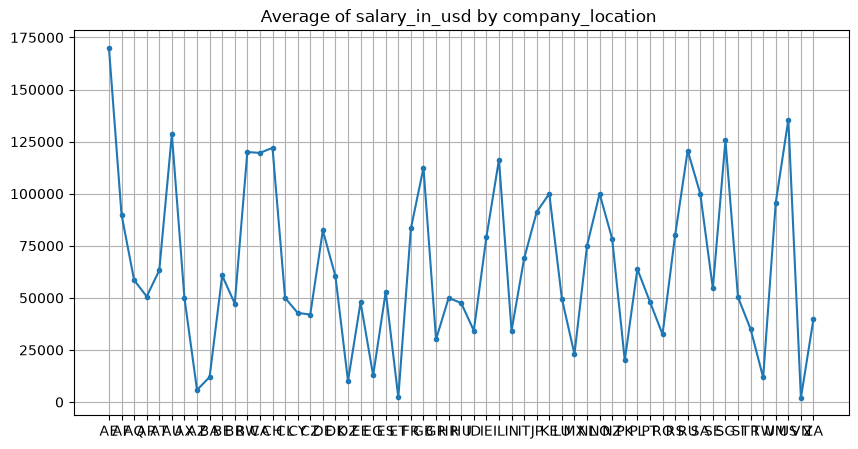

In [23]:
company_location_vs_salary_in_usd = df.groupby("company_location")["salary_in_usd"].mean()
print("\nAverage of salary_in_usd by company_location:")
print(company_location_vs_salary_in_usd)
plt.figure(figsize=(10,5))
plt.plot(
    company_location_vs_salary_in_usd.index,
    company_location_vs_salary_in_usd.values,
    marker="."
)

plt.title("Average of salary_in_usd by company_location ")
plt.xlabel = ("company_location")
plt.ylabel = ("salary_in_usd")
plt.grid(True)
plt.show()

In [24]:
df.columns

Index(['Work_Year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size', 'Salary_Updated'],
      dtype='str')

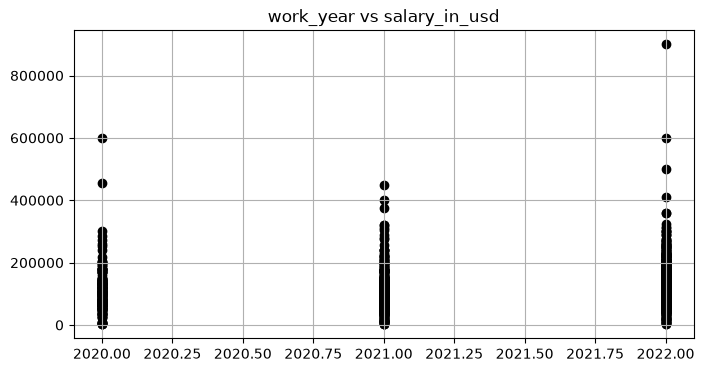

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
plt.scatter(df["Work_Year"], df["salary_in_usd"], color="black")

plt.title("work_year vs salary_in_usd")
plt.xlabel = ("Work_Year")
plt.ylabel = ("salary_in_usd")
plt.grid(True)

plt.show()

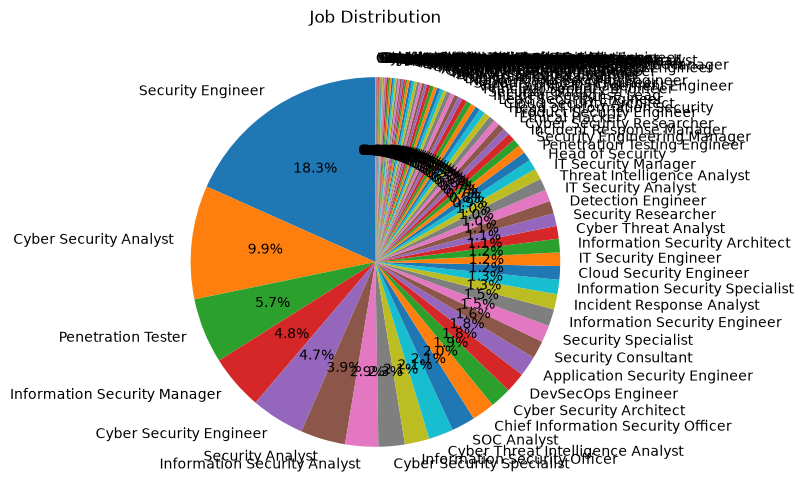

In [31]:
job = df["job_title"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(job,
        labels=job.index,
        autopct="%1.1f%%",
        startangle=90)

plt.title("Job Distribution")
plt.show()

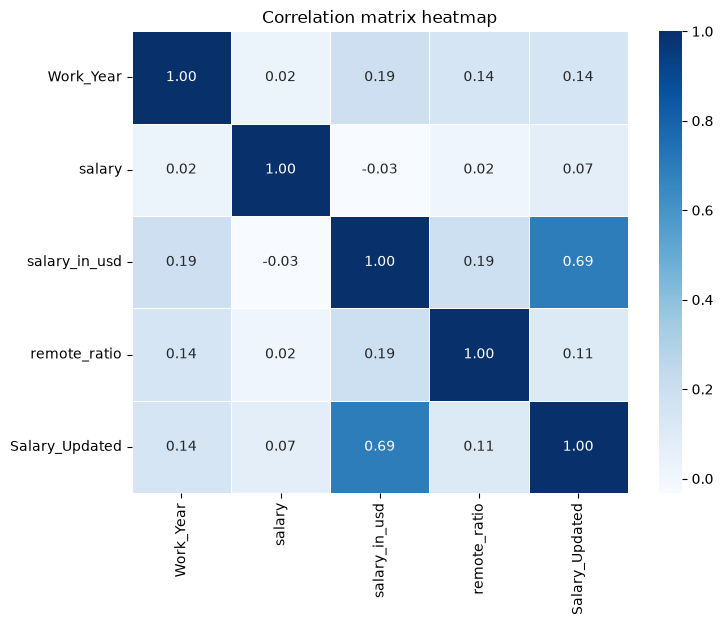

In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
correlation_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(8,6))
sns.heatmap(
    correlation_matrix,
    annot = True,
    cmap = "Blues",
    fmt = ".2f",
    linewidths = 0.5
)
plt.title("Correlation matrix heatmap")
plt.show()

First 5 Rows:
   Work_Year experience_level employment_type                     job_title  \
0       2022               EN              FT  Information Security Officer   
1       2022               SE              FT              Security Officer   
2       2022               SE              FT              Security Officer   
3       2022               SE              FT             Security Engineer   
4       2022               SE              FT             Security Engineer   

   salary salary_currency  salary_in_usd employee_residence  remote_ratio  \
0   68000             EUR          72762                 DE           100   
1  123400             USD         123400                 US             0   
2   88100             USD          88100                 US             0   
3  163575             USD         163575                 US           100   
4  115800             USD         115800                 US           100   

  company_location company_size  Salary_Updated 

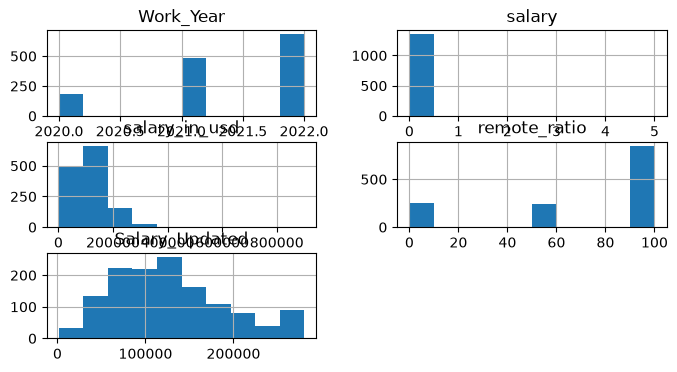

In [34]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
print("First 5 Rows:")
print(df.head())
print("\nLast 5 Rows:")
print(df.tail())
print("\nDataset Information:")
print(df.info())
print("\nStatistical Summary:")
print(df.describe())
print("\nShape of Dataset:")
print(df.shape)
df.hist(figsize=(8,4))
plt.title("Feature Distributions")
plt.show()
